In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pydataset import data
from sklearn.cluster import KMeans
from scipy.spatial.distance import cdist

In [2]:
df=data("sat.act")
df=df.dropna(how='any')
df.head()

,gender,education,age,ACT,SATV,SATQ
29442,2,3,19,24,500,500.0
29457,2,3,23,35,600,500.0
29498,2,3,20,21,480,470.0
29503,1,4,27,26,550,520.0
29504,1,2,33,31,600,550.0


## Determine no. of clusters

In [3]:
distortions=[]
K=range(1,10)# no. of clusters
for k in K:
    kmeanModel=KMeans(n_clusters=k).fit(df)
    distortions.append(sum(np.min(cdist(df,
                                       kmeanModel.cluster_centers_,'euclidean'),
                                 axis=1))/df.shape[0])
    print(distortions)

[np.float64(138.75344536281915)]
[np.float64(138.75344536281915), np.float64(96.17431511474145)]
[np.float64(138.75344536281915), np.float64(96.17431511474145), np.float64(78.37105118502518)]
[np.float64(138.75344536281915), np.float64(96.17431511474145), np.float64(78.37105118502518), np.float64(72.24320015092964)]
[np.float64(138.75344536281915), np.float64(96.17431511474145), np.float64(78.37105118502518), np.float64(72.24320015092964), np.float64(66.38432157531166)]
[np.float64(138.75344536281915), np.float64(96.17431511474145), np.float64(78.37105118502518), np.float64(72.24320015092964), np.float64(66.38432157531166), np.float64(60.019290831936644)]
[np.float64(138.75344536281915), np.float64(96.17431511474145), np.float64(78.37105118502518), np.float64(72.24320015092964), np.float64(66.38432157531166), np.float64(60.019290831936644), np.float64(55.58216337957021)]
[np.float64(138.75344536281915), np.float64(96.17431511474145), np.float64(78.37105118502518), np.float64(72.2432001

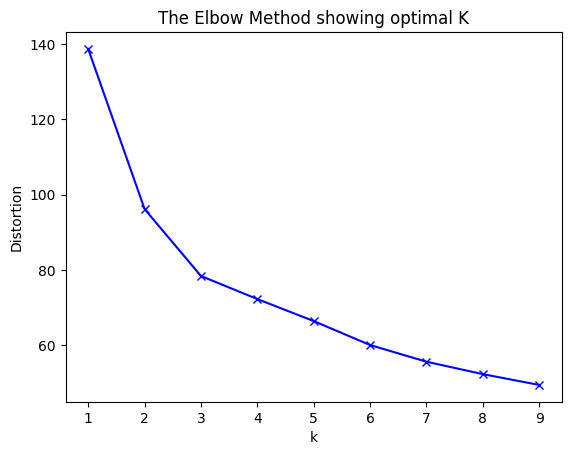

In [4]:
plt.plot(K,distortions,'bx-')
plt.xlabel('k')
plt.ylabel('Distortion')
plt.title('The Elbow Method showing optimal K')
plt.show()


## Create KMeans Cluster

In [6]:
km=KMeans(3,init='k-means++',random_state=3425)
km.fit(df.values)

KMeans(n_clusters=3, random_state=3425)

In [7]:
df['predict']=km.predict(df.values)
df[:5]

,gender,education,age,ACT,SATV,SATQ,predict
29442,2,3,19,24,500,500.0,2
29457,2,3,23,35,600,500.0,0
29498,2,3,20,21,480,470.0,2
29503,1,4,27,26,550,520.0,0
29504,1,2,33,31,600,550.0,0


In [8]:
print(df.groupby('predict').ACT.mean())
print(df.groupby('predict').age.mean())
print(df.groupby('predict').SATV.mean())
print(df.groupby('predict').SATQ.mean())
print(df.groupby('predict').education.mean())

predict
0    27.531136
1    31.547945
2    23.655738
Name: ACT, dtype: float64
predict
0    26.761905
1    24.921233
2    24.852459
Name: age, dtype: float64
predict
0    590.391941
1    703.202055
2    443.950820
Name: SATV, dtype: float64
predict
0    582.963370
1    705.520548
2    443.098361
Name: SATQ, dtype: float64
predict
0    3.336996
1    3.164384
2    2.819672
Name: education, dtype: float64


<Axes: xlabel='predict'>

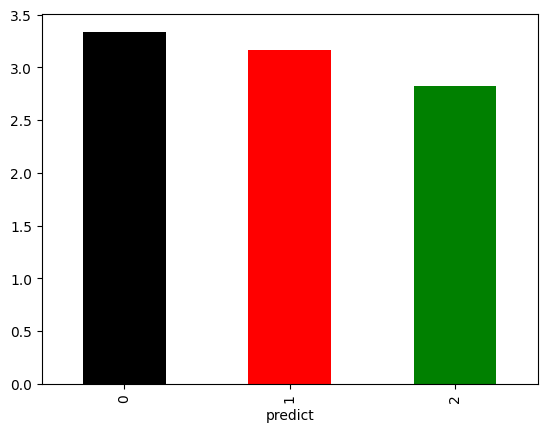

In [11]:
(df.groupby('predict').education.mean()).plot(kind='bar',color=['black','red','green'])

## By Gender

In [14]:
print(pd.crosstab(df['predict'],df['gender']))

gender     1    2
predict          
0         83  190
1        119  173
2         43   79


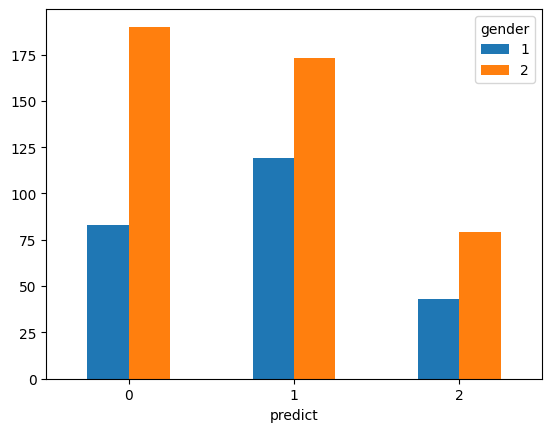

In [16]:
crosstab=pd.crosstab(df['predict'],df['gender'])
barplot=crosstab.plot.bar(rot=0)

## By Education

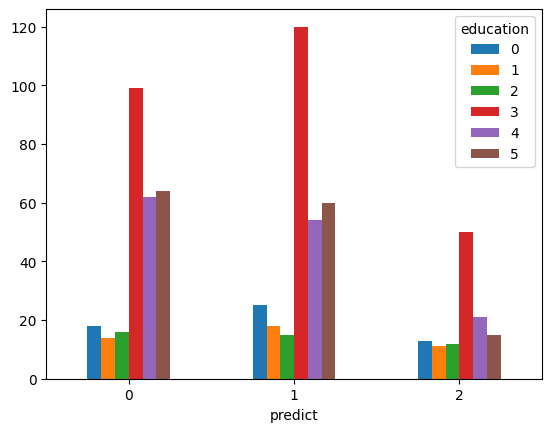

In [17]:
crosstab=pd.crosstab(df['predict'],df['education'])
barplot=crosstab.plot.bar(rot=0)

## Visual of Clusters

In [18]:
clust_map={2:'Weak',0:'Average',1:'Strong'}
df['perf']=df.predict.map(clust_map)
df.head()

,gender,education,age,ACT,SATV,SATQ,predict,perf
29442,2,3,19,24,500,500.0,2,Weak
29457,2,3,23,35,600,500.0,0,Average
29498,2,3,20,21,480,470.0,2,Weak
29503,1,4,27,26,550,520.0,0,Average
29504,1,2,33,31,600,550.0,0,Average


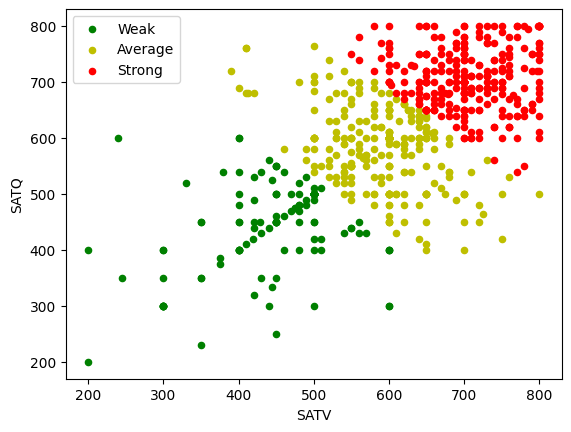

In [21]:
d_color={'Weak':'g','Average':'y','Strong':'r'}
fig, ax=plt.subplots()
for clust in clust_map.values():
    color=d_color[clust]
    df[df.perf==clust].plot(kind='scatter',x='SATV',y='SATQ',label=clust,ax=ax,color=color)